In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import time

Duration in milliseconds:  1783.5743427276611
Duration in milliseconds:  1830.9085369110107


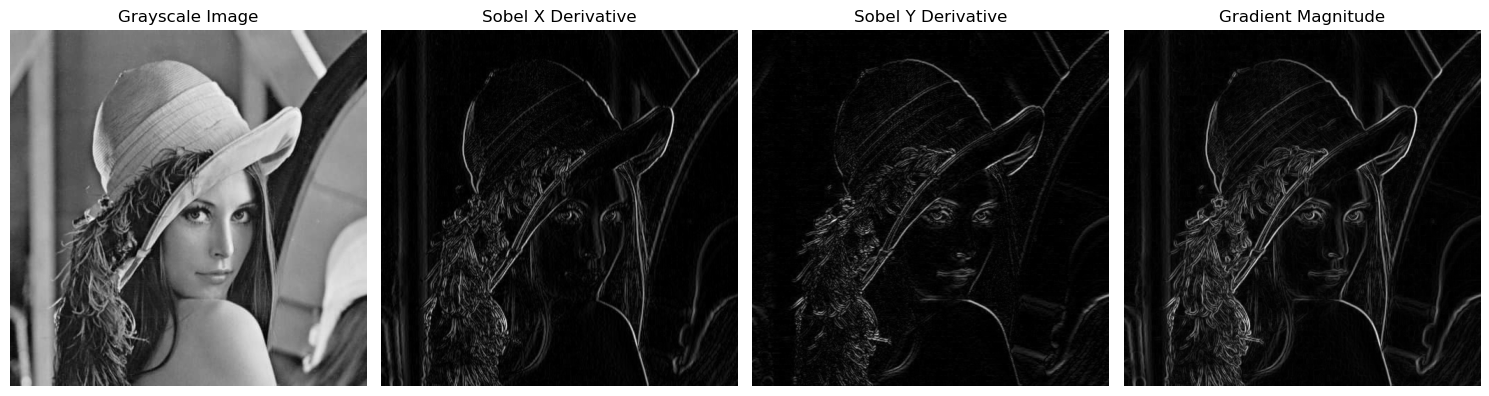

In [ ]:
def rgb_2_gray(img, mode='lut'):
    if mode == 'lut':
        return np.round(img[:,:,0] * 0.2126 + img[:,:,1] * 0.7152 + img[:,:,2] * 0.0722)
    else:
        return np.round(img[:,:,0] * 0.2126 + img[:,:,1] * 0.587 + img[:,:,2] * 0.114)
    

def sobel(img, filter):
    # TODO: implement sobel filtering e.g. with 4 foor loops
    img = img.astype(float)
    height, width = filter.shape
    img_height, img_width = img.shape

    output_height = img_height - height + 1
    output_width = img_width - width + 1
    
    filtered_img = np.zeros((output_height, output_width))

    for y_out in range(output_height):
        for x_out in range(output_width):
            y_in_start = y_out
            y_in_end = y_out + height
            x_in_start = x_out
            x_in_end = x_out + width
            
            img_patch = img[y_in_start:y_in_end, x_in_start:x_in_end]

            convolution_sum = np.sum(img_patch * filter)
            filtered_img[y_out, x_out] = convolution_sum
    return filtered_img


img = io.imread("lena.jpg")
gray = rgb_2_gray(img)

height, width = gray.shape

# TODO: define filter in x in y direction
filter_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

filter_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

start = time.time()
# TODO: filter image in x direction (sobel(gray, filter_x))
filtered_x = sobel(gray, filter_x)
end = time.time()
duration = end - start
print("Duration in milliseconds: ", duration*1000)

start_y = time.time()
# TODO: filter image in y direction (sobel(gray, filter_y))

filtered_y = sobel(gray, filter_y)
end_y = time.time()
duration_y = end_y-start_y
print("Duration in milliseconds: ", duration_y*1000)


# TODO compute Gradient magnitude
def grad_mag(filtered_x, filzered_y):
    magnitude = np.sqrt(filtered_x**2 + filtered_y**2)
    return magnitude

gradient_mag = grad_mag(filtered_x, filtered_y)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(np.abs(filtered_x), cmap='gray')
plt.title('Sobel X Derivative')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(np.abs(filtered_y), cmap='gray')
plt.title('Sobel Y Derivative')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(gradient_mag, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()